In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
words = open('names.txt', 'r').read().splitlines()

In [ ]:
chars = sorted(list(set(''.join(words))))

s_to_i = {s:i+1 for i,s in enumerate(chars)}
s_to_i['.'] = 0

i_to_s = {i:s for s,i in s_to_i.items()}

In [ ]:
block_size = 3
X, Y = [], []

for w in words:
    context = [0] * block_size

    for ch in w + '.':
        ix = s_to_i[ch]

        X.append(context)
        Y.append(ix)

        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [ ]:
g = torch.Generator().manual_seed(2147483647)

In [ ]:
C = torch.randn((27, 2), generator=g)

In [ ]:
C

In [ ]:
emb = C[X]
emb

In [ ]:
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)

In [ ]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h

In [ ]:
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

In [ ]:
logits = h @ W2 + b2

In [ ]:
counts = logits.exp()
counts

In [ ]:
probs = counts / counts.sum(1, keepdim=True)

In [ ]:
loss = -probs[torch.arange(32), Y].log().mean()
loss

In [99]:
g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [100]:
sum(p.nelement() for p in parameters)  # number of parameters in total

3481

In [101]:
C.nelement()
C.shape

torch.Size([27, 2])

In [102]:
for p in parameters:
    p.requires_grad = True

In [103]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [ ]:
lri = []
lossi = []

for i in range(1000):
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))

    # forward pass
    emb = C[X[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    # backward pass
    for p in parameters: 
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())

print(loss.item())

20.665454864501953
20.348674774169922
19.439796447753906
18.179838180541992
19.09954261779785
21.774208068847656
22.194351196289062
19.21945571899414
20.640087127685547
19.080236434936523
21.015911102294922
19.48697853088379
18.202499389648438
18.120458602905273
22.3975887298584
18.81251335144043
19.51011848449707
22.458545684814453
19.23051643371582
18.28669548034668
17.646610260009766
20.77547836303711
19.558547973632812
19.724720001220703
19.942485809326172
18.23567771911621
16.756431579589844
17.698068618774414
20.307130813598633
19.230506896972656
19.053150177001953
18.586029052734375
17.805299758911133
19.381576538085938
17.88098907470703
20.567663192749023
19.228139877319336
19.861431121826172
21.446226119995117
15.967652320861816
16.21433448791504
16.758220672607422
18.09721565246582
19.202898025512695
19.681074142456055
20.659088134765625
17.822425842285156
15.96370792388916
16.210472106933594
19.027942657470703
18.54132652282715
20.499467849731445
16.946870803833008
19.016286

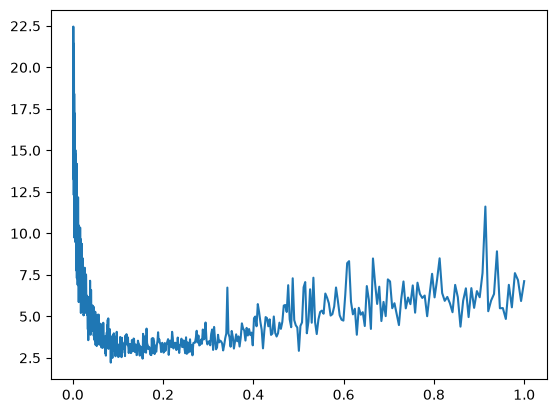

In [105]:
plt.plot(lri, lossi)

In [ ]:
torch.randint(0, X.shape[0], (32,))